# Importing Libraries and Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import re
import os

from tqdm.auto import tqdm
from collections import defaultdict

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA


from scipy.sparse import csr_matrix

from mlxtend.frequent_patterns import fpgrowth, association_rules

from itertools import combinations

from implicit.als import AlternatingLeastSquares

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

In [ ]:
def precision_at_k(recommended, relevant):
    if len(recommended) == 0:
        return 0.0
    success = len(set(recommended) & relevant)
    return success / len(recommended)


def recall_at_k(recommended, relevant):
    if len(relevant) == 0:
        return 0.0
    success = len(set(recommended) & relevant)
    return success / len(relevant)


def average_precision(recommended, relevant):
    success = 0
    ap = 0.0

    for i, item in enumerate(recommended, start=1):
        if item in relevant:
            success += 1
            ap += success / i

    if success == 0:
        return 0.0

    return ap / min(len(relevant), len(recommended))


def ndcg_at_k(recommended, relevant):
    dcg = 0.0

    for i, item in enumerate(recommended, start=1):
        if item in relevant:
            dcg += 1 / np.log2(i + 1)

    ideal_success = min(len(relevant), len(recommended))

    if ideal_success == 0:
        return 0.0

    idcg = sum(
        1 / np.log2(i + 1)
        for i in range(1, ideal_success + 1)
    )

    return dcg / idcg

In [2]:
### Creating short description using product table

def short_descript(text):
    text = str(text).lower()

    # remove numbers and measurements
    text = re.sub(r'\b\d+\s*(cm|mm|m|inch|inches|oz|ml|l|kg|g)\b', ' ', text)
    text = re.sub(r'\b\d+\b', ' ', text)

    # remove punctuation
    text = re.sub(r'[^a-z\s]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # words that usually do not define category
    noise_words = {
        'set', 'pack', 'piece', 'pieces', 'small', 'large', 'medium',
        'mini', 'big', 'assorted', 'colour', 'colours', 'red', 'blue',
        'green', 'pink', 'white', 'black', 'yellow', 'purple', 'orange',
        'brown', 'silver', 'gold', 'metal', 'wooden', 'wood', 'glass',
        'ceramic', 'paper', 'plastic', 'felt', 'cotton', 'cm', 'mm',
        'round', 'square', 'heart', 'star', 'vintage', 'retro'
    }

    words = text.split()
    words = [w for w in words if w not in noise_words]

    return ' '.join(words)

def short_descript_v2(text):
    text = str(text).lower()

    # Remove measurements like 30cm, 500ml, 2kg
    text = re.sub(r'\b\d+\s*(cm|mm|m|inch|inches|oz|ml|l|kg|g)\b', ' ', text)

    # Remove remaining standalone numbers
    text = re.sub(r'\b\d+\b', ' ', text)

    # Remove punctuation
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove only words that rarely define the product
    noise_words = {
        'set', 'pack', 'piece', 'pieces',
        'small', 'large', 'medium', 'mini', 'big',
        'assorted',
        'colour', 'colours',
        'red', 'blue', 'green', 'pink', 'white',
        'black', 'yellow', 'purple', 'orange', 'brown'
    }

    words = text.split()
    words = [w for w in words if w not in noise_words]

    return " ".join(words)

In [3]:
df_calib = pd.read_csv('calib_all_transaction.csv')
df_holdout = pd.read_csv('holdout.csv')
df_product = pd.read_csv('prod_catalog_calib..csv')
df_new = pd.read_csv('catalog_new.csv')

In [4]:
df_calib['Invoice'] = df_calib['Invoice'].astype(str).str.upper().str.strip()
df_calib['InvoiceDate'] = pd.to_datetime(df_calib['InvoiceDate'])
df_calib["Customer_ID"] = df_calib["Customer_ID"].astype("Int64")
df_calib["Customer_ID"] = df_calib["Customer_ID"].astype(str).str.upper().str.strip()

df_holdout['Invoice'] = df_holdout['Invoice'].astype(str).str.upper().str.strip()
df_holdout['InvoiceDate'] = pd.to_datetime(df_holdout['InvoiceDate'])
df_holdout["Customer_ID"] = df_holdout["Customer_ID"].astype("Int64")
df_holdout["Customer_ID"] = df_holdout["Customer_ID"].astype(str).str.upper().str.strip()

In [5]:
print('df_calib')
df_calib.info()

print('df_holdout')
df_holdout.info()

print('df_product')
df_product.info()

print('df_new')
df_new.info()

df_calib
<class 'pandas.DataFrame'>
RangeIndex: 478907 entries, 0 to 478906
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      478907 non-null  str           
 1   StockCode    478907 non-null  str           
 2   Quantity     478907 non-null  float64       
 3   line_amount  478907 non-null  float64       
 4   InvoiceDate  478907 non-null  datetime64[us]
 5   Customer_ID  381765 non-null  str           
 6   Country      478907 non-null  str           
 7   Price        478907 non-null  float64       
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 29.2 MB
df_holdout
<class 'pandas.DataFrame'>
RangeIndex: 512646 entries, 0 to 512645
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      512646 non-null  str           
 1   StockCode    512646 non-null  str           
 2   Quantity 

# Customer Segmentation

In [6]:
# ==========================================================
# Novelty rate from calibration data
#
# For each customer:
#   - sort invoices chronologically
#   - invoice 1 is used only to initialize history
#   - for invoice 2..n:
#       novelty_rate = (# products in current invoice not seen before) / (# products in current invoice)
#
# Outputs:
#    customer_novelty_summary
# ==========================================================

# Keep only valid rows
df = df_calib.dropna(subset=["Customer_ID", "Invoice", "StockCode", "InvoiceDate"]).copy()

# Build invoice-level baskets: one row per customer-invoice-date
invoice_level = (
    df.groupby(["Customer_ID", "Invoice", "InvoiceDate"], as_index=False)["StockCode"]
      .agg(lambda s: list(pd.unique(s)))
      .rename(columns={"StockCode": "products"})
)

# Sort chronologically within each customer
invoice_level = invoice_level.sort_values(
    ["Customer_ID", "InvoiceDate", "Invoice"]
).reset_index(drop=True)

invoice_results = []
customer_results = []

for customer_id, g in invoice_level.groupby("Customer_ID", sort=False):
    seen_products = set()
    novelty_scores = []

    g = g.sort_values(["InvoiceDate", "Invoice"])

    for invoice_pos, (_, row) in enumerate(g.iterrows()):
        current_products = set(row["products"])
        invoice_size = len(current_products)

        # Skip scoring the first invoice because there is no prior history
        if len(seen_products) > 0 and invoice_size > 0:
            new_products = current_products - seen_products
            novelty_rate = len(new_products) / invoice_size

            # n = 1 for second invoice, 2 for third, ...
            n = invoice_pos
            
            weight = 3.3 - 2.2 * np.exp(-0.1 * n)
            
            weighted_novelty = weight * novelty_rate
            
            novelty_scores.append(weighted_novelty)

        # Update history after scoring
        seen_products.update(current_products)

    customer_avg_novelty = np.mean(novelty_scores) if len(novelty_scores) > 0 else np.nan

    customer_results.append({
        "Customer_ID": customer_id,
        "num_scored_invoices": len(novelty_scores),
        "avg_novelty_rate": customer_avg_novelty
    })

# Final outputs
customer_novelty_summary = pd.DataFrame(customer_results).sort_values(
    "avg_novelty_rate", ascending=False
).reset_index(drop=True)


print("\nCustomer-level novelty summary:")
print(customer_novelty_summary.head())

print("\nCustomer novelty rate distribution:")
print(customer_novelty_summary["avg_novelty_rate"].describe())


Customer-level novelty summary:
  Customer_ID  num_scored_invoices  avg_novelty_rate
0       17961                   61          2.222856
1       17888                   12          1.973117
2       12748                  114          1.852467
3       14952                   20          1.801107
4       15581                   21          1.784884

Customer novelty rate distribution:
count    2835.000000
mean        1.027239
std         0.329062
min         0.000000
25%         0.855513
50%         1.100202
75%         1.276039
max         2.222856
Name: avg_novelty_rate, dtype: float64


In [7]:
customer_novelty_summary.to_csv('novelty.csv')

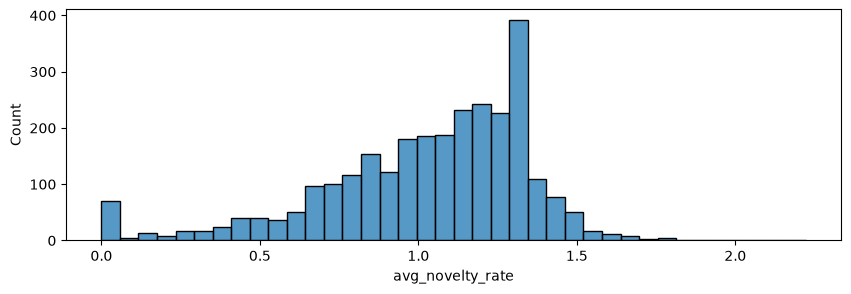

In [8]:
plt.figure(figsize=(10,3))
sns.histplot(customer_novelty_summary['avg_novelty_rate'])
plt.show()

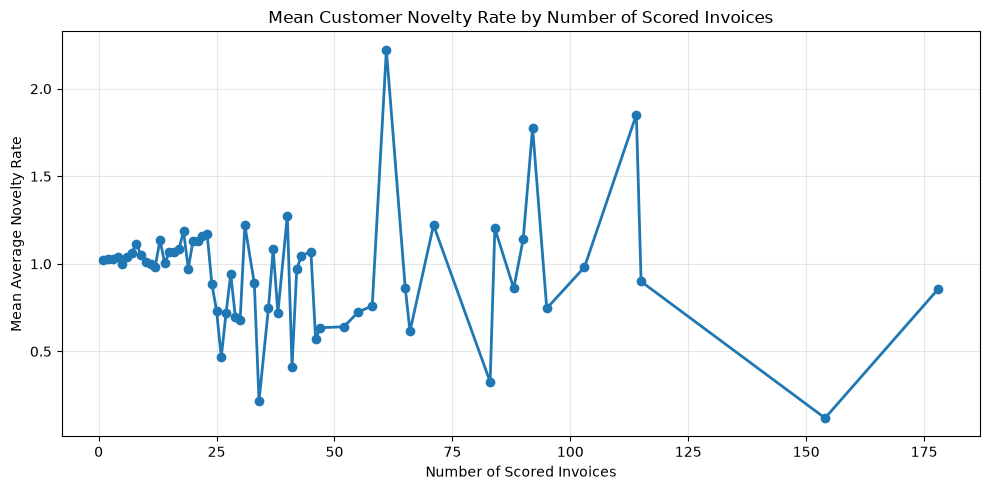

   num_scored_invoices  mean_avg_novelty_rate  num_customers
0                    1               1.022103            815
1                    2               1.028402            512
2                    3               1.027821            377
3                    4               1.037976            241
4                    5               1.000441            184


In [9]:
# ==========================================================
# Mean novelty rate by number of scored invoices
# ==========================================================

plot_df = (
    customer_novelty_summary
    .dropna(subset=["avg_novelty_rate"])
    .groupby("num_scored_invoices", as_index=False)
    .agg(
        mean_avg_novelty_rate=("avg_novelty_rate", "mean"),
        num_customers=("Customer_ID", "count")
    )
)

plt.figure(figsize=(10, 5))
plt.plot(
    plot_df["num_scored_invoices"],
    plot_df["mean_avg_novelty_rate"],
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Scored Invoices")
plt.ylabel("Mean Average Novelty Rate")
plt.title("Mean Customer Novelty Rate by Number of Scored Invoices")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optional: inspect the aggregated data
print(plot_df.head())

In [10]:
customer_novelty_summary.info()

<class 'pandas.DataFrame'>
RangeIndex: 4253 entries, 0 to 4252
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          4253 non-null   str    
 1   num_scored_invoices  4253 non-null   int64  
 2   avg_novelty_rate     2835 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 99.8 KB


In [11]:
# ==========================================================
# Customer segmentation by avg_novelty_rate
#
# repeat shopper   : avg_novelty_rate < 0.65
# dynamic shopper  : avg_novelty_rate >= 0.65
# infrequent shopper: avg_novelty_rate is null / unknown
# ==========================================================

threshold = 0.65

customer_novelty_summary["shopper_type"] = np.select(
    [
        customer_novelty_summary["avg_novelty_rate"].isna(),
        customer_novelty_summary["avg_novelty_rate"] < threshold,
        customer_novelty_summary["avg_novelty_rate"] >= threshold,
    ],
    [
        "infrequent_shopper",
        "repeat_shopper",
        "dynamic_shopper",
    ],
    default="infrequent_shopper"
)

repeat_shoppers = customer_novelty_summary.loc[
    customer_novelty_summary["shopper_type"] == "repeat_shopper",
    "Customer_ID"
].tolist()

dynamic_shoppers = customer_novelty_summary.loc[
    customer_novelty_summary["shopper_type"] == "dynamic_shopper",
    "Customer_ID"
].tolist()

infrequent_shoppers = customer_novelty_summary.loc[
    customer_novelty_summary["shopper_type"] == "infrequent_shopper",
    "Customer_ID"
].tolist()

print("Repeat shoppers:", len(repeat_shoppers))
print("Dynamic shoppers:", len(dynamic_shoppers))
print("Infrequent shoppers:", len(infrequent_shoppers))

print("\nSample:")
print(customer_novelty_summary.head())

Repeat shoppers: 324
Dynamic shoppers: 2511
Infrequent shoppers: 1418

Sample:
  Customer_ID  num_scored_invoices  avg_novelty_rate     shopper_type
0       17961                   61          2.222856  dynamic_shopper
1       17888                   12          1.973117  dynamic_shopper
2       12748                  114          1.852467  dynamic_shopper
3       14952                   20          1.801107  dynamic_shopper
4       15581                   21          1.784884  dynamic_shopper


# Adding embedding using sentence transformer

In [12]:
df_product['short_description'] = df_product['Description'].apply( short_descript )
df_product['short_description2'] = df_product['Description'].apply( short_descript_v2 )

df_new['short_description'] = df_new['Description'].apply( short_descript )
df_new['short_description2'] = df_new['Description'].apply( short_descript_v2 )

In [13]:
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    df_product['Description'].tolist(),
    show_progress_bar=True
)

embeddings_short = model.encode(
    df_product['short_description'].tolist(),
    show_progress_bar=True
)

embeddings_short2 = model.encode(
    df_product['short_description2'].tolist(),
    show_progress_bar=True
)


df_product["embeddings"] = list(embeddings)

df_product["embeddings_short"] = list(embeddings_short)

df_product["embeddings_short2"] = list(embeddings_short2)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/128 [00:00<?, ?it/s]

Batches:   0%|          | 0/128 [00:00<?, ?it/s]

Batches:   0%|          | 0/128 [00:00<?, ?it/s]

In [14]:
embeddings = model.encode(
    df_new['Description'].tolist(),
    show_progress_bar=True
)

embeddings_short = model.encode(
    df_new['short_description'].tolist(),
    show_progress_bar=True
)

embeddings_short2 = model.encode(
    df_new['short_description2'].tolist(),
    show_progress_bar=True
)


df_new["embeddings"] = list(embeddings)
df_new["embeddings_short"] = list(embeddings_short)
df_new["embeddings_short2"] = list(embeddings_short2)

Batches:   0%|          | 0/21 [00:00<?, ?it/s]

Batches:   0%|          | 0/21 [00:00<?, ?it/s]

Batches:   0%|          | 0/21 [00:00<?, ?it/s]

In [15]:
print('df_calib')
df_calib.info()

print('df_holdout')
df_holdout.info()

print('df_product')
df_product.info()

df_calib
<class 'pandas.DataFrame'>
RangeIndex: 478907 entries, 0 to 478906
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      478907 non-null  str           
 1   StockCode    478907 non-null  str           
 2   Quantity     478907 non-null  float64       
 3   line_amount  478907 non-null  float64       
 4   InvoiceDate  478907 non-null  datetime64[us]
 5   Customer_ID  381765 non-null  str           
 6   Country      478907 non-null  str           
 7   Price        478907 non-null  float64       
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 29.2 MB
df_holdout
<class 'pandas.DataFrame'>
RangeIndex: 512646 entries, 0 to 512645
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      512646 non-null  str           
 1   StockCode    512646 non-null  str           
 2   Quantity 

# Baseline Model. global popularity

In [17]:
# -------------------------------------------------
# Global popularity ranking from calibration
# -------------------------------------------------
global_popular = (
    df_calib
    .groupby("StockCode")
    .agg(
        frequency=("Invoice", "count"),
        quantity=("Quantity", "sum"),
        spend=("line_amount", "sum"),
        last_purchase=("InvoiceDate", "max")
    )
    .reset_index()
    .sort_values(
        ["frequency", "last_purchase"],
        ascending=[False, False]
    )
)

global_ranked_items = global_popular["StockCode"].tolist()

# -------------------------------------------------
# Customer item sets from calibration and holdout
# -------------------------------------------------
calib_items_by_customer = (
    df_calib
    .dropna(subset=["Customer_ID"])
    .groupby("Customer_ID")["StockCode"]
    .apply(set)
    .to_dict()
)

holdout_items_by_customer = (
    df_holdout
    .dropna(subset=["Customer_ID"])
    .groupby("Customer_ID")["StockCode"]
    .apply(set)
    .to_dict()
)

eval_customers = sorted(
    set(calib_items_by_customer.keys()) & set(holdout_items_by_customer.keys())
)

print("Number of eval customers:", len(eval_customers))


# -------------------------------------------------
# Repeat-purchase evaluation
#    (same rec list, compare against all holdout items)
# -------------------------------------------------
repeat_results = []

for customer in eval_customers:
    recs = global_ranked_items[:10]
    relevant = holdout_items_by_customer[customer]

    repeat_results.append({
        "Customer_ID": customer,
        "Precision@10": precision_at_k(recs, relevant),
        "Recall@10": recall_at_k(recs, relevant),
        "MAP@10": average_precision(recs, relevant),
        "NDCG@10": ndcg_at_k(recs, relevant),
    })

repeat_results = pd.DataFrame(repeat_results)
print("\nRepeat purchase evaluation:")
print(repeat_results.mean(numeric_only=True))

Number of eval customers: 2696

Repeat purchase evaluation:
Precision@10    0.152077
Recall@10       0.031702
MAP@10          0.089251
NDCG@10         0.172826
dtype: float64

Discovery evaluation:
Precision@10    0.070941
Recall@10       0.016644
MAP@10          0.032522
NDCG@10         0.077048
dtype: float64


In [18]:
# -------------------------------------------------
# Helper: evaluate one customer segment
# -------------------------------------------------
def evaluate_customer_segment(segment_name, customer_set):
    segment_customers = sorted(
        set(eval_customers) & set(customer_set)
    )

    print(f"\n==============================")
    print(f"{segment_name}")
    print(f"Customers in segment: {len(segment_customers)}")
    print(f"==============================")

    # Repeat-purchase evaluation
    repeat_results = []

    for customer in segment_customers:
        recs = global_ranked_items[:10]
        relevant = holdout_items_by_customer[customer]

        repeat_results.append({
            "Customer_ID": customer,
            "Precision@10": precision_at_k(recs, relevant),
            "Recall@10": recall_at_k(recs, relevant),
            "MAP@10": average_precision(recs, relevant),
            "NDCG@10": ndcg_at_k(recs, relevant),
        })

    repeat_results = pd.DataFrame(repeat_results)
    print("\nRepeat purchase evaluation:")
    print(repeat_results.mean(numeric_only=True))

    # Discovery evaluation
    discovery_results = []

    for customer in segment_customers:
        seen = calib_items_by_customer.get(customer, set())
        recs = [item for item in global_ranked_items if item not in seen][:10]

        calib_items = calib_items_by_customer.get(customer, set())
        holdout_items = holdout_items_by_customer.get(customer, set())
        relevant = holdout_items - calib_items

        if len(relevant) == 0:
            continue

        discovery_results.append({
            "Customer_ID": customer,
            "Precision@10": precision_at_k(recs, relevant),
            "Recall@10": recall_at_k(recs, relevant),
            "MAP@10": average_precision(recs, relevant),
            "NDCG@10": ndcg_at_k(recs, relevant),
        })

    discovery_results = pd.DataFrame(discovery_results)
    print("\nDiscovery evaluation:")
    print(discovery_results.mean(numeric_only=True))

    # New catalog item evaluation
    new_item_results = []
    new_items = set(df_new["StockCode"])

    for customer in segment_customers:
        recs = [item for item in global_ranked_items if item in new_items][:10]
        relevant = holdout_items_by_customer[customer] & new_items

        if len(relevant) == 0:
            continue

        new_item_results.append({
            "Customer_ID": customer,
            "Precision@10": precision_at_k(recs, relevant),
            "Recall@10": recall_at_k(recs, relevant),
            "MAP@10": average_precision(recs, relevant),
            "NDCG@10": ndcg_at_k(recs, relevant),
        })

    new_item_results = pd.DataFrame(new_item_results)
    print("\nNew Catalog Item Evaluation:")
    print(new_item_results.mean(numeric_only=True))

    return repeat_results, discovery_results, new_item_results


# -------------------------------------------------
# Run evaluation for the three customer groups
# -------------------------------------------------
repeat_metrics, repeat_discovery_metrics, repeat_new_item_metrics = evaluate_customer_segment(
    "Repeat shoppers",
    repeat_shoppers
)

dynamic_metrics, dynamic_discovery_metrics, dynamic_new_item_metrics = evaluate_customer_segment(
    "Dynamic shoppers",
    dynamic_shoppers
)

infrequent_metrics, infrequent_discovery_metrics, infrequent_new_item_metrics = evaluate_customer_segment(
    "Infrequent shoppers",
    infrequent_shoppers
)


Repeat shoppers
Customers in segment: 235

Repeat purchase evaluation:
Precision@10    0.140851
Recall@10       0.044196
MAP@10          0.084642
NDCG@10         0.162836
dtype: float64

Discovery evaluation:
Precision@10    0.050711
Recall@10       0.014567
MAP@10          0.021199
NDCG@10         0.054039
dtype: float64

New Catalog Item Evaluation:
Precision@10    0.0
Recall@10       0.0
MAP@10          0.0
NDCG@10         0.0
dtype: float64

Dynamic shoppers
Customers in segment: 1917

Repeat purchase evaluation:
Precision@10    0.172144
Recall@10       0.029407
MAP@10          0.101501
NDCG@10         0.193565
dtype: float64

Discovery evaluation:
Precision@10    0.075686
Recall@10       0.015006
MAP@10          0.034197
NDCG@10         0.080627
dtype: float64

New Catalog Item Evaluation:
Precision@10    0.0
Recall@10       0.0
MAP@10          0.0
NDCG@10         0.0
dtype: float64

Infrequent shoppers
Customers in segment: 544

Repeat purchase evaluation:
Precision@10    0.0862

# Baseline Model-1. repeat purchase

In [19]:
# ==========================================================
# 1) Build Repeat Purchase model (Frequency + Recency)
# ==========================================================

customer_product = (
    df_calib
    .dropna(subset=["Customer_ID"])
    .groupby(["Customer_ID", "StockCode"])
    .agg(
        frequency=("Invoice", "count"),
        quantity=("Quantity", "sum"),
        spend=("line_amount", "sum"),
        last_purchase=("InvoiceDate", "max")
    )
    .reset_index()
)

customer_product = customer_product.sort_values(
    ["Customer_ID", "frequency", "last_purchase"],
    ascending=[True, False, False]
)

recommendations = (
    customer_product
    .groupby("Customer_ID")["StockCode"]
    .apply(list)
    .to_dict()
)

# ==========================================================
# 2) Customer item sets
# ==========================================================

calib_items_by_customer = (
    df_calib
    .dropna(subset=["Customer_ID"])
    .groupby("Customer_ID")["StockCode"]
    .apply(set)
    .to_dict()
)

holdout_items_by_customer = (
    df_holdout
    .dropna(subset=["Customer_ID"])
    .groupby("Customer_ID")["StockCode"]
    .apply(set)
    .to_dict()
)

eval_customers = sorted(
    set(calib_items_by_customer.keys()) &
    set(holdout_items_by_customer.keys())
)

print("Number of eval customers:", len(eval_customers))

# ==========================================================
# 3) Recommendation functions
# ==========================================================

def recommend_repeat_purchase(customer_id, top_k=10):
    return recommendations.get(customer_id, [])[:top_k]


def recommend_repeat_purchase_discovery(customer_id, top_k=10):

    seen = calib_items_by_customer.get(customer_id, set())

    recs = [
        item
        for item in recommendations.get(customer_id, [])
        if item not in seen
    ]

    return recs[:top_k]


def get_discovery_ground_truth(customer_id):

    seen = calib_items_by_customer.get(customer_id, set())

    future = holdout_items_by_customer.get(customer_id, set())

    return future - seen


# ==========================================================
# 4) Repeat Purchase Evaluation
# ==========================================================

repeat_results = []

for customer in eval_customers:

    recs = recommend_repeat_purchase(customer, top_k=10)

    relevant = holdout_items_by_customer[customer]

    repeat_results.append({

        "Customer_ID": customer,

        "Precision@10": precision_at_k(recs, relevant),

        "Recall@10": recall_at_k(recs, relevant),

        "MAP@10": average_precision(recs, relevant),

        "NDCG@10": ndcg_at_k(recs, relevant)

    })

repeat_results = pd.DataFrame(repeat_results)

print("\nRepeat Purchase Evaluation")

print(repeat_results.mean(numeric_only=True))


# ==========================================================
# 5) Product Discovery Evaluation
# ==========================================================

discovery_results = []

for customer in eval_customers:

    recs = recommend_repeat_purchase_discovery(customer, top_k=10)

    relevant = get_discovery_ground_truth(customer)

    if len(relevant) == 0:
        continue

    discovery_results.append({

        "Customer_ID": customer,

        "Precision@10": precision_at_k(recs, relevant),

        "Recall@10": recall_at_k(recs, relevant),

        "MAP@10": average_precision(recs, relevant),

        "NDCG@10": ndcg_at_k(recs, relevant)

    })

discovery_results = pd.DataFrame(discovery_results)

print("\nProduct Discovery Evaluation")

print(discovery_results.mean(numeric_only=True))

Number of eval customers: 2696

Repeat Purchase Evaluation
Precision@10    0.377641
Recall@10       0.104787
MAP@10          0.299294
NDCG@10         0.407552
dtype: float64

Product Discovery Evaluation
Precision@10    0.0
Recall@10       0.0
MAP@10          0.0
NDCG@10         0.0
dtype: float64


In [20]:
# ==========================================================
# 0) Customer segments
# ==========================================================

threshold = 0.65

repeat_shoppers = set(
    customer_novelty_summary.loc[
        customer_novelty_summary["avg_novelty_rate"] < threshold,
        "Customer_ID"
    ].dropna()
)

dynamic_shoppers = set(
    customer_novelty_summary.loc[
        customer_novelty_summary["avg_novelty_rate"] >= threshold,
        "Customer_ID"
    ].dropna()
)

infrequent_shoppers = set(
    customer_novelty_summary.loc[
        customer_novelty_summary["avg_novelty_rate"].isna(),
        "Customer_ID"
    ].dropna()
)

print("Repeat shoppers:", len(repeat_shoppers))
print("Dynamic shoppers:", len(dynamic_shoppers))
print("Infrequent shoppers:", len(infrequent_shoppers))


# ==========================================================
# 1) Build Repeat Purchase model (Frequency + Recency)
# ==========================================================

customer_product = (
    df_calib
    .dropna(subset=["Customer_ID"])
    .groupby(["Customer_ID", "StockCode"])
    .agg(
        frequency=("Invoice", "count"),
        quantity=("Quantity", "sum"),
        spend=("line_amount", "sum"),
        last_purchase=("InvoiceDate", "max")
    )
    .reset_index()
)

customer_product = customer_product.sort_values(
    ["Customer_ID", "frequency", "last_purchase"],
    ascending=[True, False, False]
)

recommendations = (
    customer_product
    .groupby("Customer_ID")["StockCode"]
    .apply(list)
    .to_dict()
)

# ==========================================================
# 2) Customer item sets
# ==========================================================

calib_items_by_customer = (
    df_calib
    .dropna(subset=["Customer_ID"])
    .groupby("Customer_ID")["StockCode"]
    .apply(set)
    .to_dict()
)

holdout_items_by_customer = (
    df_holdout
    .dropna(subset=["Customer_ID"])
    .groupby("Customer_ID")["StockCode"]
    .apply(set)
    .to_dict()
)

eval_customers = sorted(
    set(calib_items_by_customer.keys()) &
    set(holdout_items_by_customer.keys())
)

print("Number of eval customers:", len(eval_customers))

# ==========================================================
# 3) Recommendation functions
# ==========================================================

def recommend_repeat_purchase(customer_id, top_k=10):
    return recommendations.get(customer_id, [])[:top_k]


def recommend_repeat_purchase_discovery(customer_id, top_k=10):
    seen = calib_items_by_customer.get(customer_id, set())

    recs = [
        item
        for item in recommendations.get(customer_id, [])
        if item not in seen
    ]

    return recs[:top_k]


def get_discovery_ground_truth(customer_id):
    seen = calib_items_by_customer.get(customer_id, set())
    future = holdout_items_by_customer.get(customer_id, set())
    return future - seen


# ==========================================================
# 4) Helper: evaluate one customer segment
# ==========================================================

def evaluate_repeat_purchase_segment(segment_name, customer_set):
    segment_customers = sorted(set(eval_customers) & set(customer_set))

    print(f"\n==============================")
    print(f"{segment_name}")
    print(f"Customers in segment: {len(segment_customers)}")
    print(f"==============================")

    # Repeat Purchase Evaluation
    repeat_results = []

    for customer in segment_customers:
        recs = recommend_repeat_purchase(customer, top_k=10)
        relevant = holdout_items_by_customer[customer]

        repeat_results.append({
            "Customer_ID": customer,
            "Precision@10": precision_at_k(recs, relevant),
            "Recall@10": recall_at_k(recs, relevant),
            "MAP@10": average_precision(recs, relevant),
            "NDCG@10": ndcg_at_k(recs, relevant)
        })

    repeat_results = pd.DataFrame(repeat_results)
    print("\nRepeat Purchase Evaluation")
    print(repeat_results.mean(numeric_only=True))

    # Product Discovery Evaluation
    discovery_results = []

    for customer in segment_customers:
        recs = recommend_repeat_purchase_discovery(customer, top_k=10)
        relevant = get_discovery_ground_truth(customer)

        if len(relevant) == 0:
            continue

        discovery_results.append({
            "Customer_ID": customer,
            "Precision@10": precision_at_k(recs, relevant),
            "Recall@10": recall_at_k(recs, relevant),
            "MAP@10": average_precision(recs, relevant),
            "NDCG@10": ndcg_at_k(recs, relevant)
        })

    discovery_results = pd.DataFrame(discovery_results)
    print("\nProduct Discovery Evaluation")
    print(discovery_results.mean(numeric_only=True))

    return repeat_results, discovery_results


# ==========================================================
# 5) Run evaluation for the three customer sets
# ==========================================================

repeat_metrics, repeat_discovery_metrics = evaluate_repeat_purchase_segment(
    "Repeat shoppers",
    repeat_shoppers
)

dynamic_metrics, dynamic_discovery_metrics = evaluate_repeat_purchase_segment(
    "Dynamic shoppers",
    dynamic_shoppers
)

infrequent_metrics, infrequent_discovery_metrics = evaluate_repeat_purchase_segment(
    "Infrequent shoppers",
    infrequent_shoppers
)

Repeat shoppers: 324
Dynamic shoppers: 2511
Infrequent shoppers: 1418
Number of eval customers: 2696

Repeat shoppers
Customers in segment: 235

Repeat Purchase Evaluation
Precision@10    0.558100
Recall@10       0.262446
MAP@10          0.521124
NDCG@10         0.628008
dtype: float64

Product Discovery Evaluation
Precision@10    0.0
Recall@10       0.0
MAP@10          0.0
NDCG@10         0.0
dtype: float64

Dynamic shoppers
Customers in segment: 1917

Repeat Purchase Evaluation
Precision@10    0.407027
Recall@10       0.088566
MAP@10          0.321174
NDCG@10         0.438873
dtype: float64

Product Discovery Evaluation
Precision@10    0.0
Recall@10       0.0
MAP@10          0.0
NDCG@10         0.0
dtype: float64

Infrequent shoppers
Customers in segment: 544

Repeat Purchase Evaluation
Precision@10    0.196134
Recall@10       0.093842
MAP@10          0.126364
NDCG@10         0.201944
dtype: float64

Product Discovery Evaluation
Precision@10    0.0
Recall@10       0.0
MAP@10         

# Baseline Model. Market Basket (Item Co-occurrence)

In [21]:
# ==========================================================
# 1. Build item-item co-occurrence matrix
# ==========================================================

cooccur = defaultdict(lambda: defaultdict(int))

# One basket per invoice
invoice_items = (
    df_calib
    .groupby("Invoice")["StockCode"]
    .apply(lambda x: sorted(set(x)))
)

for basket in invoice_items:

    for item1, item2 in combinations(basket, 2):

        cooccur[item1][item2] += 1
        cooccur[item2][item1] += 1

print("Number of products with neighbors:", len(cooccur))

# ==========================================================
# 2. Customer purchase history
# ==========================================================

customer_history = (
    df_calib
    .dropna(subset=["Customer_ID"])
    .groupby("Customer_ID")["StockCode"]
    .apply(set)
    .to_dict()
)

holdout_items = (
    df_holdout
    .dropna(subset=["Customer_ID"])
    .groupby("Customer_ID")["StockCode"]
    .apply(set)
    .to_dict()
)

eval_customers = sorted(
    set(customer_history.keys()) &
    set(holdout_items.keys())
)

print("Number of eval customers:", len(eval_customers))

# ==========================================================
# 3. Recommendation function
# ==========================================================

def recommend_market_basket(customer_id, top_k=10):

    purchased = customer_history.get(customer_id, set())

    scores = defaultdict(int)

    # Aggregate co-occurrence scores
    for item in purchased:

        for neighbor, count in cooccur.get(item, {}).items():

            scores[neighbor] += count

    # Remove already purchased products
    for item in purchased:
        scores.pop(item, None)

    ranked = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return [item for item, _ in ranked[:top_k]]

# ==========================================================
# 4. Discovery ground truth
# ==========================================================

def discovery_ground_truth(customer_id):

    return (
        holdout_items.get(customer_id, set())
        - customer_history.get(customer_id, set())
    )

# ==========================================================
# 5. Repeat Purchase Evaluation
# ==========================================================

repeat_results = []

for customer in eval_customers:

    recs = recommend_market_basket(customer, top_k=10)

    relevant = holdout_items[customer]

    repeat_results.append({

        "Customer_ID": customer,

        "Precision@10": precision_at_k(recs, relevant),

        "Recall@10": recall_at_k(recs, relevant),

        "MAP@10": average_precision(recs, relevant),

        "NDCG@10": ndcg_at_k(recs, relevant)

    })

repeat_results = pd.DataFrame(repeat_results)

print("\nRepeat Purchase Evaluation")

print(repeat_results.mean(numeric_only=True))

# ==========================================================
# 6. Product Discovery Evaluation
# ==========================================================

discovery_results = []

for customer in eval_customers:

    recs = recommend_market_basket(customer, top_k=10)

    relevant = discovery_ground_truth(customer)

    if len(relevant) == 0:
        continue

    discovery_results.append({

        "Customer_ID": customer,

        "Precision@10": precision_at_k(recs, relevant),

        "Recall@10": recall_at_k(recs, relevant),

        "MAP@10": average_precision(recs, relevant),

        "NDCG@10": ndcg_at_k(recs, relevant)

    })

discovery_results = pd.DataFrame(discovery_results)

print("\nProduct Discovery Evaluation")

print(discovery_results.mean(numeric_only=True))

Number of products with neighbors: 4066
Number of eval customers: 2696

Repeat Purchase Evaluation
Precision@10    0.087240
Recall@10       0.018252
MAP@10          0.040174
NDCG@10         0.092207
dtype: float64

Product Discovery Evaluation
Precision@10    0.089226
Recall@10       0.026053
MAP@10          0.042439
NDCG@10         0.095987
dtype: float64


In [22]:
# ==========================================================
# Repeat Shoppers
# ==========================================================

segment_customers = sorted(set(eval_customers) & repeat_shoppers)

print("\n====================================================")
print("Repeat Shoppers")
print("Customers evaluated:", len(segment_customers))

# ---------------- Repeat Purchase ----------------
repeat_results = []

for customer in segment_customers:

    recs = recommend_market_basket(customer, top_k=10)
    relevant = holdout_items[customer]

    repeat_results.append({
        "Customer_ID": customer,
        "Precision@10": precision_at_k(recs, relevant),
        "Recall@10": recall_at_k(recs, relevant),
        "MAP@10": average_precision(recs, relevant),
        "NDCG@10": ndcg_at_k(recs, relevant)
    })

repeat_results = pd.DataFrame(repeat_results)

print("\nRepeat Purchase Evaluation")
print(repeat_results.mean(numeric_only=True))

# ---------------- Discovery ----------------
discovery_results = []

for customer in segment_customers:

    recs = recommend_market_basket(customer, top_k=10)
    relevant = discovery_ground_truth(customer)

    if len(relevant) == 0:
        continue

    discovery_results.append({
        "Customer_ID": customer,
        "Precision@10": precision_at_k(recs, relevant),
        "Recall@10": recall_at_k(recs, relevant),
        "MAP@10": average_precision(recs, relevant),
        "NDCG@10": ndcg_at_k(recs, relevant)
    })

discovery_results = pd.DataFrame(discovery_results)

print("\nProduct Discovery Evaluation")
print(discovery_results.mean(numeric_only=True))


# ==========================================================
# Dynamic Shoppers
# ==========================================================

segment_customers = sorted(set(eval_customers) & dynamic_shoppers)

print("\n====================================================")
print("Dynamic Shoppers")
print("Customers evaluated:", len(segment_customers))

# ---------------- Repeat Purchase ----------------
repeat_results = []

for customer in segment_customers:

    recs = recommend_market_basket(customer, top_k=10)
    relevant = holdout_items[customer]

    repeat_results.append({
        "Customer_ID": customer,
        "Precision@10": precision_at_k(recs, relevant),
        "Recall@10": recall_at_k(recs, relevant),
        "MAP@10": average_precision(recs, relevant),
        "NDCG@10": ndcg_at_k(recs, relevant)
    })

repeat_results = pd.DataFrame(repeat_results)

print("\nRepeat Purchase Evaluation")
print(repeat_results.mean(numeric_only=True))

# ---------------- Discovery ----------------
discovery_results = []

for customer in segment_customers:

    recs = recommend_market_basket(customer, top_k=10)
    relevant = discovery_ground_truth(customer)

    if len(relevant) == 0:
        continue

    discovery_results.append({
        "Customer_ID": customer,
        "Precision@10": precision_at_k(recs, relevant),
        "Recall@10": recall_at_k(recs, relevant),
        "MAP@10": average_precision(recs, relevant),
        "NDCG@10": ndcg_at_k(recs, relevant)
    })

discovery_results = pd.DataFrame(discovery_results)

print("\nProduct Discovery Evaluation")
print(discovery_results.mean(numeric_only=True))


# ==========================================================
# Infrequent Shoppers
# ==========================================================

segment_customers = sorted(set(eval_customers) & infrequent_shoppers)

print("\n====================================================")
print("Infrequent Shoppers")
print("Customers evaluated:", len(segment_customers))

# ---------------- Repeat Purchase ----------------
repeat_results = []

for customer in segment_customers:

    recs = recommend_market_basket(customer, top_k=10)
    relevant = holdout_items[customer]

    repeat_results.append({
        "Customer_ID": customer,
        "Precision@10": precision_at_k(recs, relevant),
        "Recall@10": recall_at_k(recs, relevant),
        "MAP@10": average_precision(recs, relevant),
        "NDCG@10": ndcg_at_k(recs, relevant)
    })

repeat_results = pd.DataFrame(repeat_results)

print("\nRepeat Purchase Evaluation")
print(repeat_results.mean(numeric_only=True))

# ---------------- Discovery ----------------
discovery_results = []

for customer in segment_customers:

    recs = recommend_market_basket(customer, top_k=10)
    relevant = discovery_ground_truth(customer)

    if len(relevant) == 0:
        continue

    discovery_results.append({
        "Customer_ID": customer,
        "Precision@10": precision_at_k(recs, relevant),
        "Recall@10": recall_at_k(recs, relevant),
        "MAP@10": average_precision(recs, relevant),
        "NDCG@10": ndcg_at_k(recs, relevant)
    })

discovery_results = pd.DataFrame(discovery_results)

print("\nProduct Discovery Evaluation")
print(discovery_results.mean(numeric_only=True))


Repeat Shoppers
Customers evaluated: 235

Repeat Purchase Evaluation
Precision@10    0.063830
Recall@10       0.021228
MAP@10          0.032864
NDCG@10         0.073798
dtype: float64

Product Discovery Evaluation
Precision@10    0.071090
Recall@10       0.037285
MAP@10          0.041481
NDCG@10         0.087217
dtype: float64

Dynamic Shoppers
Customers evaluated: 1917

Repeat Purchase Evaluation
Precision@10    0.092906
Recall@10       0.015902
MAP@10          0.041874
NDCG@10         0.096173
dtype: float64

Product Discovery Evaluation
Precision@10    0.093935
Recall@10       0.023283
MAP@10          0.043288
NDCG@10         0.098489
dtype: float64

Infrequent Shoppers
Customers evaluated: 544

Repeat Purchase Evaluation
Precision@10    0.077390
Recall@10       0.025247
MAP@10          0.037340
NDCG@10         0.086186
dtype: float64

Product Discovery Evaluation
Precision@10    0.079584
Recall@10       0.031501
MAP@10          0.039778
NDCG@10         0.090520
dtype: float64


# Content-based Semantic Model

In [23]:
df_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 652 entries, 0 to 651
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   StockCode           652 non-null    str   
 1   Description         652 non-null    str   
 2   short_description   652 non-null    str   
 3   short_description2  652 non-null    str   
 4   embeddings          652 non-null    object
 5   embeddings_short    652 non-null    object
 6   embeddings_short2   652 non-null    object
dtypes: object(3), str(4)
memory usage: 35.8+ KB


In [24]:
df_product.columns

Index(['StockCode', 'Description', 'minprice', 'maxprice', 'avgprice',
       'std_of_price', 'short_description', 'short_description2', 'embeddings',
       'embeddings_short', 'embeddings_short2'],
      dtype='str')

In [25]:
# ==========================================================
# 1) Prepare product embeddings
#    Change embedding_col if you want to use a different one
# ==========================================================
embedding_col = "embeddings_short2"

df_product = df_product.dropna(subset=["StockCode", embedding_col])

In [26]:
# Keep only embeddings with consistent dimensionality
dim = df_product[embedding_col].iloc[0].shape[0]
df_product = df_product[df_product[embedding_col].apply(lambda x: x.shape[0] == dim)].copy()

stock_to_emb = dict(zip(df_product["StockCode"], df_product[embedding_col]))

item_ids = df_product["StockCode"].tolist()
item_emb_matrix = np.vstack(df_product[embedding_col].to_numpy()).astype(np.float32)

# L2-normalize item embeddings for cosine similarity via dot product
item_norms = np.linalg.norm(item_emb_matrix, axis=1, keepdims=True)
item_norms[item_norms == 0] = 1.0
item_emb_matrix = item_emb_matrix / item_norms

item_to_idx = {s: i for i, s in enumerate(item_ids)}
idx_to_item = {i: s for s, i in item_to_idx.items()}

print("Number of items with embeddings:", len(item_ids))
print("Embedding dimension:", dim)

# ==========================================================
# 2) Build calibration customer history with weights
#    Weight choice: purchase frequency
#    You can switch to quantity or spend if you want
# ==========================================================
cust_prod = (
    df_calib
    .dropna(subset=["Customer_ID", "StockCode"])
    .groupby(["Customer_ID", "StockCode"])
    .agg(
        frequency=("Invoice", "count"),
        quantity=("Quantity", "sum"),
        spend=("line_amount", "sum"),
        last_purchase=("InvoiceDate", "max")
    )
    .reset_index()
)

# Choose weighting scheme
weight_col = "frequency"   # options: "frequency", "quantity", "spend"

# Optional recency decay on top of the weight:
# Set USE_RECENCY = True if you want a stronger semantic baseline.
USE_RECENCY = False
LAMBDA = 0.01
reference_date = df_calib["InvoiceDate"].max()

if USE_RECENCY:
    cust_prod["days_since"] = (reference_date - cust_prod["last_purchase"]).dt.days
    cust_prod["score"] = cust_prod[weight_col] * np.exp(-LAMBDA * cust_prod["days_since"])
else:
    cust_prod["score"] = cust_prod[weight_col].astype(float)

# Keep only products that have embeddings
cust_prod = cust_prod[cust_prod["StockCode"].isin(stock_to_emb)].copy()

# Build customer profile vectors
customer_vector = {}

for customer_id, grp in cust_prod.groupby("Customer_ID"):
    scores = grp["score"].to_numpy(dtype=np.float32)
    if scores.sum() <= 0:
        continue

    embs = np.vstack(grp["StockCode"].map(stock_to_emb).to_numpy()).astype(np.float32)

    vec = np.average(embs, axis=0, weights=scores)

    # Normalize customer vector for cosine similarity
    norm = np.linalg.norm(vec)
    if norm > 0:
        vec = vec / norm

    customer_vector[customer_id] = vec

print("Number of customers with semantic profiles:", len(customer_vector))

# ==========================================================
# 3) Calibration / holdout item sets
# ==========================================================
calib_items_by_customer = (
    df_calib
    .dropna(subset=["Customer_ID"])
    .groupby("Customer_ID")["StockCode"]
    .apply(set)
    .to_dict()
)

holdout_items_by_customer = (
    df_holdout
    .dropna(subset=["Customer_ID"])
    .groupby("Customer_ID")["StockCode"]
    .apply(set)
    .to_dict()
)

eval_customers = sorted(
    set(calib_items_by_customer.keys()) & set(holdout_items_by_customer.keys())
)

print("Number of eval customers:", len(eval_customers))

# ==========================================================
# 4) Recommendation functions
# ==========================================================
def recommend_semantic(customer_id, top_k=10, filter_seen=False):
    """
    Content-based semantic recommender using customer profile vector
    and cosine similarity to all product embeddings.
    """
    uvec = customer_vector.get(customer_id)
    if uvec is None:
        return []

    scores = item_emb_matrix @ uvec  # cosine similarity because both are normalized

    seen = calib_items_by_customer.get(customer_id, set())
    if filter_seen:
        # remove previously seen items by setting their scores to -inf
        for stock in seen:
            idx = item_to_idx.get(stock)
            if idx is not None:
                scores[idx] = -np.inf

    top_idx = np.argpartition(-scores, kth=min(top_k, len(scores) - 1))[:top_k * 5]
    top_idx = top_idx[np.argsort(-scores[top_idx])]

    recs = []
    for i in top_idx:
        stock = idx_to_item[int(i)]
        if stock is None:
            continue
        if filter_seen and stock in seen:
            continue
        recs.append(stock)
        if len(recs) == top_k:
            break

    return recs

# ==========================================================
# 5) Repeat Purchase Evaluation
# ==========================================================
repeat_results = []

for customer in tqdm(eval_customers, desc="Semantic repeat evaluation"):
    recs = recommend_semantic(customer, top_k=10, filter_seen=False)
    relevant = holdout_items_by_customer[customer]

    repeat_results.append({
        "Customer_ID": customer,
        "Precision@10": precision_at_k(recs, relevant),
        "Recall@10": recall_at_k(recs, relevant),
        "MAP@10": average_precision(recs, relevant),
        "NDCG@10": ndcg_at_k(recs, relevant),
    })

repeat_results = pd.DataFrame(repeat_results)
print("\nContent-based Semantic Model | Repeat Purchase Evaluation")
print(repeat_results.mean(numeric_only=True))

# ==========================================================
# 6) Product Discovery Evaluation
# ==========================================================
discovery_results = []

for customer in tqdm(eval_customers, desc="Semantic discovery evaluation"):
    
    relevant = holdout_items_by_customer.get(customer, set()) - calib_items_by_customer.get(customer, set())
    if len(relevant) == 0:
        continue

    recs = recommend_semantic(customer, top_k=10, filter_seen=True)

    discovery_results.append({
        "Customer_ID": customer,
        "Precision@10": precision_at_k(recs, relevant),
        "Recall@10": recall_at_k(recs, relevant),
        "MAP@10": average_precision(recs, relevant),
        "NDCG@10": ndcg_at_k(recs, relevant),
    })

discovery_results = pd.DataFrame(discovery_results)
print("\nContent-based Semantic Model | Product Discovery Evaluation")
print(discovery_results.mean(numeric_only=True))


##========================================


# ==========================================================
# 0) Basic cleanup
# ==========================================================
df_calib["StockCode"] = df_calib["StockCode"].astype(str).str.strip()
df_holdout["StockCode"] = df_holdout["StockCode"].astype(str).str.strip()
df_new["StockCode"] = df_new["StockCode"].astype(str).str.strip()
df_calib["Customer_ID"] = df_calib["Customer_ID"].astype("string")
df_holdout["Customer_ID"] = df_holdout["Customer_ID"].astype("string")


# ==========================================================
# 1) Prepare embeddings for calibration products
#    (used to build customer vectors)
# ==========================================================


df_product[embedding_col] = df_product[embedding_col].apply(
    lambda x: np.asarray(x, dtype=np.float32)
)

dim = df_product[embedding_col].iloc[0].shape[0]

stock_to_emb = dict(zip(df_product["StockCode"], df_product[embedding_col]))

item_ids = df_product["StockCode"].tolist()
item_emb_matrix = np.vstack(df_product[embedding_col].to_numpy()).astype(np.float32)

# L2 normalize
item_norms = np.linalg.norm(item_emb_matrix, axis=1, keepdims=True)
item_norms[item_norms == 0] = 1.0
item_emb_matrix = item_emb_matrix / item_norms

item_to_idx = {s: i for i, s in enumerate(item_ids)}
idx_to_item = {i: s for s, i in item_to_idx.items()}

print("Calibration catalog items with embeddings:", len(item_ids))
print("Embedding dimension:", dim)

# ==========================================================
# 2) Build calibration customer profiles
# ==========================================================
cust_prod = (
    df_calib
    .dropna(subset=["Customer_ID", "StockCode"])
    .groupby(["Customer_ID", "StockCode"])
    .agg(
        frequency=("Invoice", "count"),
        quantity=("Quantity", "sum"),
        spend=("line_amount", "sum"),
        last_purchase=("InvoiceDate", "max")
    )
    .reset_index()
)

weight_col = "frequency"   # or "quantity" or "spend"

USE_RECENCY = False
LAMBDA = 0.01
reference_date = df_calib["InvoiceDate"].max()

if USE_RECENCY:
    cust_prod["days_since"] = (reference_date - cust_prod["last_purchase"]).dt.days
    cust_prod["score"] = cust_prod[weight_col] * np.exp(-LAMBDA * cust_prod["days_since"])
else:
    cust_prod["score"] = cust_prod[weight_col].astype(float)

cust_prod = cust_prod[cust_prod["StockCode"].isin(stock_to_emb)].copy()

customer_vector = {}

for customer_id, grp in cust_prod.groupby("Customer_ID"):
    scores = grp["score"].to_numpy(dtype=np.float32)
    if scores.sum() <= 0:
        continue

    embs = np.vstack(grp["StockCode"].map(stock_to_emb).to_numpy()).astype(np.float32)
    vec = np.average(embs, axis=0, weights=scores)

    norm = np.linalg.norm(vec)
    if norm > 0:
        vec = vec / norm

    customer_vector[customer_id] = vec

print("Customers with semantic profiles:", len(customer_vector))

# ==========================================================
# 3) Prepare df_new candidate products only
#    These are the products we want to rank among themselves
# ==========================================================
new_df = df_new[["StockCode", embedding_col]].copy()
new_df = new_df.dropna(subset=["StockCode", embedding_col])

new_df[embedding_col] = new_df[embedding_col].apply(
    lambda x: np.asarray(x, dtype=np.float32)
)

# Keep only consistent embedding dimensions
new_df = new_df[new_df[embedding_col].apply(lambda x: x.shape[0] == dim)].copy()

new_item_ids = new_df["StockCode"].tolist()
new_item_emb_matrix = np.vstack(new_df[embedding_col].to_numpy()).astype(np.float32)

new_norms = np.linalg.norm(new_item_emb_matrix, axis=1, keepdims=True)
new_norms[new_norms == 0] = 1.0
new_item_emb_matrix = new_item_emb_matrix / new_norms

new_item_to_idx = {s: i for i, s in enumerate(new_item_ids)}
new_idx_to_item = {i: s for s, i in new_item_to_idx.items()}
new_products_set = set(new_item_ids)

print("df_new items with embeddings:", len(new_item_ids))

# ==========================================================
# 4) Calibration customers -> holdout items
#    Compare holdout against df_new
# ==========================================================
calib_customers = set(df_calib["Customer_ID"].dropna().unique())

holdout_items_by_customer = (
    df_holdout
    .dropna(subset=["Customer_ID"])
    .query("Customer_ID in @calib_customers")
    .groupby("Customer_ID")["StockCode"]
    .apply(lambda s: set(s.astype(str).str.strip()))
    .to_dict()
)

customers_with_new_items = []
all_holdout_items_from_calib = set()

for customer, items in holdout_items_by_customer.items():
    all_holdout_items_from_calib |= items
    overlap = items & new_products_set
    if overlap:
        customers_with_new_items.append((customer, overlap))

print("Calibration customers:", len(calib_customers))
print("Customers with holdout history:", len(holdout_items_by_customer))
print("Unique holdout items from calibration customers:", len(all_holdout_items_from_calib))
print("df_new items:", len(new_products_set))
print("Holdout ∩ df_new:", len(all_holdout_items_from_calib & new_products_set))
print("Customers who bought at least one df_new item in holdout:", len(customers_with_new_items))


# ==========================================================
# 6) Recommend ONLY from df_new candidates
# ==========================================================
def recommend_from_df_new(customer_id, top_k=10):
    uvec = customer_vector.get(customer_id)
    if uvec is None:
        return []

    scores = new_item_emb_matrix @ uvec  # cosine similarity

    top_n = min(top_k, len(scores))
    top_idx = np.argsort(-scores)[:top_n]

    return [new_idx_to_item[int(i)] for i in top_idx]

# ==========================================================
# 7) Evaluate only customers who actually bought df_new items
# ==========================================================
new_product_results = []

for customer, relevant in tqdm(customers_with_new_items, desc="New product evaluation"):
    recs = recommend_from_df_new(customer, top_k=10)

    new_product_results.append({
        "Customer_ID": customer,
        "Precision@10": precision_at_k(recs, relevant),
        "Recall@10": recall_at_k(recs, relevant),
        "MAP@10": average_precision(recs, relevant),
        "NDCG@10": ndcg_at_k(recs, relevant),
    })

new_product_results = pd.DataFrame(new_product_results)

print("\nContent-based Semantic Model | Newly Added Product Evaluation (df_new only)")
print("Customers evaluated:", len(new_product_results))
print(new_product_results.mean(numeric_only=True))

# ==========================================================
# 8) Optional sanity check for one customer
# ==========================================================
if len(customers_with_new_items) > 0:
    sample_customer, sample_relevant = customers_with_new_items[0]
    sample_recs = recommend_from_df_new(sample_customer, top_k=10)

    print("\nSample customer:", sample_customer)
    print("Relevant df_new items:", sorted(list(sample_relevant))[:10])
    print("Recommended df_new items:", sample_recs)

Number of items with embeddings: 4070
Embedding dimension: 384
Number of customers with semantic profiles: 4253
Number of eval customers: 2696


Semantic repeat evaluation:   0%|          | 0/2696 [00:00<?, ?it/s]


Content-based Semantic Model | Repeat Purchase Evaluation
Precision@10    0.112648
Recall@10       0.048569
MAP@10          0.078677
NDCG@10         0.137728
dtype: float64


Semantic discovery evaluation:   0%|          | 0/2696 [00:00<?, ?it/s]


Content-based Semantic Model | Product Discovery Evaluation
Precision@10    0.029173
Recall@10       0.012242
MAP@10          0.012853
NDCG@10         0.032210
dtype: float64
Calibration catalog items with embeddings: 4070
Embedding dimension: 384
Customers with semantic profiles: 4253
df_new items with embeddings: 652
Calibration customers: 4253
Customers with holdout history: 2696
Unique holdout items from calibration customers: 3565
df_new items: 652
Holdout ∩ df_new: 605
Customers who bought at least one df_new item in holdout: 2262


New product evaluation:   0%|          | 0/2262 [00:00<?, ?it/s]


Content-based Semantic Model | Newly Added Product Evaluation (df_new only)
Customers evaluated: 2262
Precision@10    0.104156
Recall@10       0.064995
MAP@10          0.063670
NDCG@10         0.118193
dtype: float64

Sample customer: 12347
Relevant df_new items: ['22992', '23076', '23084', '23146', '23147', '23162', '23170', '23171', '23172', '23173']
Recommended df_new items: ['23582', '23037', '23245', '23598', '23343', '23312', '23664', '23314', '23203', '23122']


In [27]:
# ==========================================================
# Segment definitions
# ==========================================================
threshold = 0.65

segments = {
    "Repeat shoppers": set(
        customer_novelty_summary.loc[
            customer_novelty_summary["avg_novelty_rate"] < threshold,
            "Customer_ID"
        ].dropna()
    ),
    "Dynamic shoppers": set(
        customer_novelty_summary.loc[
            customer_novelty_summary["avg_novelty_rate"] >= threshold,
            "Customer_ID"
        ].dropna()
    ),
    "Infrequent shoppers": set(
        customer_novelty_summary.loc[
            customer_novelty_summary["avg_novelty_rate"].isna(),
            "Customer_ID"
        ].dropna()
    )
}

for name, customer_set in segments.items():
    print(f"{name}: {len(customer_set)}")

# Keep only customers present in both calibration and holdout
eval_segments = {
    name: sorted(set(eval_customers) & customer_set)
    for name, customer_set in segments.items()
}

for name, customer_list in eval_segments.items():
    print(f"{name} eval customers: {len(customer_list)}")

# ==========================================================
# Evaluate all three segments
# ==========================================================
segment_repeat_tables = {}
segment_discovery_tables = {}

for segment_name, segment_customers in eval_segments.items():
    print(f"\n{'='*60}")
    print(segment_name)
    print(f"Customers evaluated: {len(segment_customers)}")
    print("="*60)

    # -----------------------------
    # Repeat Purchase Evaluation
    # -----------------------------
    repeat_results = []

    for customer in segment_customers:
        recs = recommend_semantic(customer, top_k=10, filter_seen=False)
        relevant = holdout_items_by_customer[customer]

        repeat_results.append({
            "Customer_ID": customer,
            "Precision@10": precision_at_k(recs, relevant),
            "Recall@10": recall_at_k(recs, relevant),
            "MAP@10": average_precision(recs, relevant),
            "NDCG@10": ndcg_at_k(recs, relevant),
        })

    repeat_results = pd.DataFrame(repeat_results)
    segment_repeat_tables[segment_name] = repeat_results

    print("\nRepeat Purchase Evaluation")
    print(repeat_results.mean(numeric_only=True))

    # -----------------------------
    # Product Discovery Evaluation
    # -----------------------------
    discovery_results = []

    for customer in segment_customers:
        relevant = (
            holdout_items_by_customer.get(customer, set())
            - calib_items_by_customer.get(customer, set())
        )

        if len(relevant) == 0:
            continue

        recs = recommend_semantic(customer, top_k=10, filter_seen=True)

        discovery_results.append({
            "Customer_ID": customer,
            "Precision@10": precision_at_k(recs, relevant),
            "Recall@10": recall_at_k(recs, relevant),
            "MAP@10": average_precision(recs, relevant),
            "NDCG@10": ndcg_at_k(recs, relevant),
        })

    discovery_results = pd.DataFrame(discovery_results)
    segment_discovery_tables[segment_name] = discovery_results

    print("\nProduct Discovery Evaluation")
    print(discovery_results.mean(numeric_only=True))

# Optional: compact comparison table
repeat_summary = pd.DataFrame({
    segment: tbl.mean(numeric_only=True)
    for segment, tbl in segment_repeat_tables.items()
}).T

discovery_summary = pd.DataFrame({
    segment: tbl.mean(numeric_only=True)
    for segment, tbl in segment_discovery_tables.items()
}).T

print("\n=== Repeat Purchase Comparison ===")
print(repeat_summary)

print("\n=== Product Discovery Comparison ===")
print(discovery_summary)

Repeat shoppers: 324
Dynamic shoppers: 2511
Infrequent shoppers: 1418
Repeat shoppers eval customers: 235
Dynamic shoppers eval customers: 1917
Infrequent shoppers eval customers: 544

Repeat shoppers
Customers evaluated: 235

Repeat Purchase Evaluation
Precision@10    0.242553
Recall@10       0.169880
MAP@10          0.236218
NDCG@10         0.338039
dtype: float64

Product Discovery Evaluation
Precision@10    0.030332
Recall@10       0.031487
MAP@10          0.022549
NDCG@10         0.043309
dtype: float64

Dynamic shoppers
Customers evaluated: 1917

Repeat Purchase Evaluation
Precision@10    0.106312
Recall@10       0.031371
MAP@10          0.063081
NDCG@10         0.120825
dtype: float64

Product Discovery Evaluation
Precision@10    0.029747
Recall@10       0.009868
MAP@10          0.012192
NDCG@10         0.031855
dtype: float64

Infrequent shoppers
Customers evaluated: 544

Repeat Purchase Evaluation
Precision@10    0.078860
Recall@10       0.056768
MAP@10          0.065577
NDCG@

In [28]:
# ==========================================================
# Segment definitions
# ==========================================================
threshold = 0.65

segments = {
    "Repeat shoppers": set(
        customer_novelty_summary.loc[
            customer_novelty_summary["avg_novelty_rate"] < threshold,
            "Customer_ID"
        ].dropna()
    ),
    "Dynamic shoppers": set(
        customer_novelty_summary.loc[
            customer_novelty_summary["avg_novelty_rate"] >= threshold,
            "Customer_ID"
        ].dropna()
    ),
    "Infrequent shoppers": set(
        customer_novelty_summary.loc[
            customer_novelty_summary["avg_novelty_rate"].isna(),
            "Customer_ID"
        ].dropna()
    )
}

# Keep only customers present in both calibration and holdout
eval_segments = {
    name: set(eval_customers) & customer_set
    for name, customer_set in segments.items()
}

for name, customer_set in eval_segments.items():
    print(f"{name}: {len(customer_set)} eval customers")

# Fast lookup from customer -> relevant df_new items
customers_with_new_items_dict = dict(customers_with_new_items)

# ==========================================================
# df_new evaluation for each segment
# ==========================================================
segment_new_product_results = {}

for segment_name, segment_customers in eval_segments.items():

    new_product_results = []

    for customer in tqdm(segment_customers, desc=f"{segment_name} | New product evaluation"):
        relevant = customers_with_new_items_dict.get(customer, set())
        if len(relevant) == 0:
            continue

        recs = recommend_from_df_new(customer, top_k=10)

        new_product_results.append({
            "Customer_ID": customer,
            "Precision@10": precision_at_k(recs, relevant),
            "Recall@10": recall_at_k(recs, relevant),
            "MAP@10": average_precision(recs, relevant),
            "NDCG@10": ndcg_at_k(recs, relevant),
        })

    new_product_results = pd.DataFrame(new_product_results)
    segment_new_product_results[segment_name] = new_product_results

    print(f"\nContent-based Semantic Model | Newly Added Product Evaluation (df_new only) | {segment_name}")
    print("Customers evaluated:", len(new_product_results))
    print(new_product_results.mean(numeric_only=True))

# Optional compact comparison table
new_product_summary = pd.DataFrame({
    segment: tbl.mean(numeric_only=True)
    for segment, tbl in segment_new_product_results.items()
}).T

print("\n=== Newly Added Product Evaluation Comparison ===")
print(new_product_summary)

Repeat shoppers: 235 eval customers
Dynamic shoppers: 1917 eval customers
Infrequent shoppers: 544 eval customers


Repeat shoppers | New product evaluation:   0%|          | 0/235 [00:00<?, ?it/s]


Content-based Semantic Model | Newly Added Product Evaluation (df_new only) | Repeat shoppers
Customers evaluated: 167
Precision@10    0.138323
Recall@10       0.149869
MAP@10          0.110440
NDCG@10         0.174744
dtype: float64


Dynamic shoppers | New product evaluation:   0%|          | 0/1917 [00:00<?, ?it/s]


Content-based Semantic Model | Newly Added Product Evaluation (df_new only) | Dynamic shoppers
Customers evaluated: 1679
Precision@10    0.113877
Recall@10       0.060964
MAP@10          0.067435
NDCG@10         0.126484
dtype: float64


Infrequent shoppers | New product evaluation:   0%|          | 0/544 [00:00<?, ?it/s]


Content-based Semantic Model | Newly Added Product Evaluation (df_new only) | Infrequent shoppers
Customers evaluated: 416
Precision@10    0.051202
Recall@10       0.047191
MAP@10          0.029700
NDCG@10         0.062029
dtype: float64

=== Newly Added Product Evaluation Comparison ===
                     Precision@10  Recall@10    MAP@10   NDCG@10
Repeat shoppers          0.138323   0.149869  0.110440  0.174744
Dynamic shoppers         0.113877   0.060964  0.067435  0.126484
Infrequent shoppers      0.051202   0.047191  0.029700  0.062029


# 2 Tower

In [29]:
# ==========================================================
# 0) Reproducibility
# ==========================================================
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ==========================================================
# 1) Prepare item semantic features
#    Item tower will use TEXT ONLY
# ==========================================================
embedding_col = "embeddings_short2"

df_product_tt = df_product[["StockCode", embedding_col]].copy()
df_product_tt = df_product_tt.dropna(subset=["StockCode", embedding_col]).copy()
df_product_tt["StockCode"] = df_product_tt["StockCode"].astype(str).str.strip()
df_product_tt[embedding_col] = df_product_tt[embedding_col].apply(
    lambda x: np.asarray(x, dtype=np.float32)
)

# Keep only consistent embedding size
dim = df_product_tt[embedding_col].iloc[0].shape[0]
df_product_tt = df_product_tt[df_product_tt[embedding_col].apply(lambda x: x.shape[0] == dim)].copy()

item_ids = df_product_tt["StockCode"].tolist()
item_to_idx = {s: i for i, s in enumerate(item_ids)}
idx_to_item = {i: s for s, i in item_to_idx.items()}

item_feat_matrix = np.vstack(df_product_tt[embedding_col].to_numpy()).astype(np.float32)
item_feat_norm = np.linalg.norm(item_feat_matrix, axis=1, keepdims=True)
item_feat_norm[item_feat_norm == 0] = 1.0
item_feat_matrix = item_feat_matrix / item_feat_norm

# Add PAD row for empty histories
pad_idx = len(item_ids)
item_feat_matrix = np.vstack([item_feat_matrix, np.zeros((1, dim), dtype=np.float32)])
item_vocab_size = len(item_ids) + 1

print("Items with embeddings:", len(item_ids))
print("Embedding dimension:", dim)

# ==========================================================
# 2) Build customer-item interaction features from calibration
#    Weight = frequency * optional recency decay
# ==========================================================
USE_RECENCY = True
LAMBDA = 0.01
reference_date = df_calib["InvoiceDate"].max()

df_calib_tt = df_calib.copy()
df_calib_tt["StockCode"] = df_calib_tt["StockCode"].astype(str).str.strip()
df_calib_tt["Customer_ID"] = df_calib_tt["Customer_ID"].astype("string")

cust_prod = (
    df_calib_tt
    .dropna(subset=["Customer_ID", "StockCode"])
    .groupby(["Customer_ID", "StockCode"])
    .agg(
        frequency=("Invoice", "count"),
        quantity=("Quantity", "sum"),
        spend=("line_amount", "sum"),
        last_purchase=("InvoiceDate", "max")
    )
    .reset_index()
)

cust_prod = cust_prod[cust_prod["StockCode"].isin(item_to_idx)].copy()

if USE_RECENCY:
    cust_prod["days_since"] = (reference_date - cust_prod["last_purchase"]).dt.days
    cust_prod["weight"] = cust_prod["frequency"] * np.exp(-LAMBDA * cust_prod["days_since"])
else:
    cust_prod["weight"] = cust_prod["frequency"].astype(float)

customer_ids = sorted(cust_prod["Customer_ID"].unique())
customer_to_idx = {c: i for i, c in enumerate(customer_ids)}
idx_to_customer = {i: c for c, i in customer_to_idx.items()}

# Full customer history: item_idx -> weight
customer_hist_map = {}
customer_seen_idx = {}

for customer_id, grp in cust_prod.groupby("Customer_ID"):
    cidx = customer_to_idx[customer_id]
    items = grp["StockCode"].map(item_to_idx).astype(int).to_list()
    weights = grp["weight"].astype(np.float32).to_list()

    customer_hist_map[cidx] = {i: w for i, w in zip(items, weights)}
    customer_seen_idx[cidx] = set(items)

print("Customers with histories:", len(customer_ids))

# ==========================================================
# 3) Training pairs (positive interactions)
# ==========================================================
pos_pairs = cust_prod[["Customer_ID", "StockCode"]].drop_duplicates().copy()
pos_pairs["cust_idx"] = pos_pairs["Customer_ID"].map(customer_to_idx)
pos_pairs["item_idx"] = pos_pairs["StockCode"].map(item_to_idx)
pos_pairs = pos_pairs.dropna(subset=["cust_idx", "item_idx"]).copy()
pos_pairs["cust_idx"] = pos_pairs["cust_idx"].astype(int)
pos_pairs["item_idx"] = pos_pairs["item_idx"].astype(int)

print("Positive pairs:", len(pos_pairs))

# ==========================================================
# 4) Dataset + collate for variable-length histories
# ==========================================================
class TwoTowerRetrievalDataset(Dataset):
    def __init__(self, pos_df, num_neg=4):
        self.samples = []
        self.num_neg = num_neg

        for row in tqdm(pos_df.itertuples(index=False), total=len(pos_df), desc="Building train samples"):
            cidx = int(row.cust_idx)
            iidx = int(row.item_idx)

            # positive sample
            self.samples.append((cidx, iidx, 1.0, True))

            # negative samples
            seen = customer_seen_idx.get(cidx, set())
            for _ in range(num_neg):
                neg = np.random.randint(0, len(item_ids))
                while neg in seen:
                    neg = np.random.randint(0, len(item_ids))
                self.samples.append((cidx, int(neg), 0.0, False))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        cidx, iidx, label, exclude_target = self.samples[idx]
        return int(cidx), int(iidx), float(label), bool(exclude_target)


def collate_fn(batch):
    cidxs, iidxs, labels, exclude_flags = zip(*batch)

    hist_items_list = []
    hist_weights_list = []

    for cidx, iidx, exclude_target in zip(cidxs, iidxs, exclude_flags):
        hist_map = customer_hist_map.get(int(cidx), {})

        if exclude_target:
            items = [it for it in hist_map.keys() if it != int(iidx)]
            weights = [hist_map[it] for it in items]
        else:
            items = list(hist_map.keys())
            weights = list(hist_map.values())

        if len(items) == 0:
            items = [pad_idx]
            weights = [0.0]

        hist_items_list.append(torch.tensor(items, dtype=torch.long))
        hist_weights_list.append(torch.tensor(weights, dtype=torch.float32))

    hist_items = pad_sequence(hist_items_list, batch_first=True, padding_value=pad_idx)
    hist_weights = pad_sequence(hist_weights_list, batch_first=True, padding_value=0.0)

    return (
        torch.tensor(cidxs, dtype=torch.long),
        torch.tensor(iidxs, dtype=torch.long),
        torch.tensor(labels, dtype=torch.float32),
        hist_items,
        hist_weights,
    )


train_ds = TwoTowerRetrievalDataset(pos_pairs, num_neg=4)
train_loader = DataLoader(
    train_ds,
    batch_size=1024,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)

# ==========================================================
# 5) Two-Tower model
#    Version 1:
#    - customer tower unchanged
#    - item tower = text only
# ==========================================================
class TwoTowerRetrievalModel(nn.Module):
    def __init__(self, num_customers, item_vocab_size, item_feat_matrix, feat_dim,
                 cust_id_dim=64, item_id_dim=64, hidden_dim=128, latent_dim=64):
        super().__init__()

        # Customer side stays the same
        self.customer_id_emb = nn.Embedding(num_customers, cust_id_dim)

        # Used only for customer history pooling
        self.item_id_emb = nn.Embedding(item_vocab_size, item_id_dim, padding_idx=pad_idx)

        # Text features for items
        self.register_buffer("item_feat_tensor", torch.tensor(item_feat_matrix, dtype=torch.float32))

        self.item_text_proj = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
        )

        self.customer_proj = nn.Sequential(
            nn.Linear(cust_id_dim + item_id_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
        )

        # Item tower now uses TEXT ONLY
        self.item_proj = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
        )

        self.logit_scale = nn.Parameter(torch.tensor(10.0))

    def encode_customer(self, cidx, hist_items, hist_weights):
        cid = self.customer_id_emb(cidx)  # [B, cust_id_dim]

        item_hist_emb = self.item_id_emb(hist_items)  # [B, L, item_id_dim]
        w = hist_weights.unsqueeze(-1)                 # [B, L, 1]

        pooled = (item_hist_emb * w).sum(dim=1) / w.sum(dim=1).clamp(min=1e-6)
        x = torch.cat([cid, pooled], dim=-1)
        z = self.customer_proj(x)
        return F.normalize(z, dim=-1)

    def encode_item(self, iidx):
        feat = self.item_feat_tensor[iidx]   # [B, feat_dim]
        text = self.item_text_proj(feat)     # [B, latent_dim]
        z = self.item_proj(text)             # no item ID here
        return F.normalize(z, dim=-1)

    def encode_item_from_feat(self, feat_tensor):
        """
        For unseen items (e.g. df_new), encode directly from feature vectors.
        feat_tensor: [N, feat_dim]
        """
        text = self.item_text_proj(feat_tensor)
        z = self.item_proj(text)
        return F.normalize(z, dim=-1)

    def forward(self, cidx, hist_items, hist_weights, iidx):
        u = self.encode_customer(cidx, hist_items, hist_weights)
        v = self.encode_item(iidx)
        logits = self.logit_scale * (u * v).sum(dim=-1)
        return logits


model = TwoTowerRetrievalModel(
    num_customers=len(customer_ids),
    item_vocab_size=item_vocab_size,
    item_feat_matrix=item_feat_matrix,
    feat_dim=dim,
    cust_id_dim=64,
    item_id_dim=64,
    hidden_dim=128,
    latent_dim=64
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.BCEWithLogitsLoss()

# ==========================================================
# 6) Train
# ==========================================================
EPOCHS = 8

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for cidx, iidx, labels, hist_items, hist_weights in tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}",
        leave=False
    ):
        cidx = cidx.to(device)
        iidx = iidx.to(device)
        labels = labels.to(device)
        hist_items = hist_items.to(device)
        hist_weights = hist_weights.to(device)

        optimizer.zero_grad()
        logits = model(cidx, hist_items, hist_weights, iidx)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)

    avg_loss = total_loss / len(train_ds)
    print(f"Epoch {epoch+1}/{EPOCHS} | loss = {avg_loss:.4f}")

# ==========================================================
# 7) Precompute item latent vectors for known catalog items
# ==========================================================
model.eval()
with torch.no_grad():
    all_item_idx = torch.arange(len(item_ids), dtype=torch.long, device=device)
    item_latent = model.encode_item(all_item_idx).cpu().numpy()
    item_latent = item_latent / np.linalg.norm(item_latent, axis=1, keepdims=True).clip(min=1e-12)

# ==========================================================
# 8) Build evaluation sets
# ==========================================================
df_holdout_tt = df_holdout.copy()
df_holdout_tt["StockCode"] = df_holdout_tt["StockCode"].astype(str).str.strip()
df_holdout_tt["Customer_ID"] = df_holdout_tt["Customer_ID"].astype("string")

calib_items_by_customer = (
    df_calib_tt
    .dropna(subset=["Customer_ID"])
    .groupby("Customer_ID")["StockCode"]
    .apply(set)
    .to_dict()
)

holdout_items_by_customer = (
    df_holdout_tt
    .dropna(subset=["Customer_ID"])
    .groupby("Customer_ID")["StockCode"]
    .apply(set)
    .to_dict()
)

eval_customers = sorted(set(customer_ids) & set(holdout_items_by_customer.keys()))
print("Number of eval customers:", len(eval_customers))

# ==========================================================
# 9) Recommendation function
# ==========================================================
def recommend_two_tower(customer_id, top_k=10, filter_seen=False):
    cidx = customer_to_idx.get(customer_id)
    if cidx is None:
        return []

    hist_map = customer_hist_map.get(cidx, {})
    items = list(hist_map.keys())
    weights = list(hist_map.values())

    if len(items) == 0:
        items = [pad_idx]
        weights = [0.0]

    cidx_t = torch.tensor([cidx], dtype=torch.long, device=device)
    hist_items_t = torch.tensor([items], dtype=torch.long, device=device)
    hist_weights_t = torch.tensor([weights], dtype=torch.float32, device=device)

    with torch.no_grad():
        u = model.encode_customer(cidx_t, hist_items_t, hist_weights_t).cpu().numpy()[0]

    scores = item_latent @ u  # cosine similarity in latent space

    seen = calib_items_by_customer.get(customer_id, set())

    if filter_seen:
        for stock in seen:
            idx = item_to_idx.get(stock)
            if idx is not None:
                scores[idx] = -np.inf

    # get enough candidates before truncating to top_k
    k = min(len(scores) - 1, max(top_k * 10, top_k))
    if k < 1:
        return []

    top_idx = np.argpartition(-scores, kth=k)[:k]
    top_idx = top_idx[np.argsort(-scores[top_idx])]

    recs = []
    for i in top_idx:
        stock = idx_to_item.get(int(i))
        if stock is None:
            continue
        if filter_seen and stock in seen:
            continue
        recs.append(stock)
        if len(recs) == top_k:
            break

    return recs


def discovery_ground_truth(customer_id):
    return holdout_items_by_customer.get(customer_id, set()) - calib_items_by_customer.get(customer_id, set())

# ==========================================================
# 10) Repeat Purchase Evaluation
# ==========================================================
repeat_results = []

for customer in tqdm(eval_customers, desc="Two-tower repeat evaluation"):
    recs = recommend_two_tower(customer, top_k=10, filter_seen=False)
    relevant = holdout_items_by_customer[customer]

    repeat_results.append({
        "Customer_ID": customer,
        "Precision@10": precision_at_k(recs, relevant),
        "Recall@10": recall_at_k(recs, relevant),
        "MAP@10": average_precision(recs, relevant),
        "NDCG@10": ndcg_at_k(recs, relevant),
    })

repeat_results = pd.DataFrame(repeat_results)
print("\nTwo-Tower Model | Repeat Purchase Evaluation")
print(repeat_results.mean(numeric_only=True))

# ==========================================================
# 11) Product Discovery Evaluation
# ==========================================================
discovery_results = []

for customer in tqdm(eval_customers, desc="Two-tower discovery evaluation"):
    relevant = discovery_ground_truth(customer)
    if len(relevant) == 0:
        continue

    recs = recommend_two_tower(customer, top_k=10, filter_seen=True)

    discovery_results.append({
        "Customer_ID": customer,
        "Precision@10": precision_at_k(recs, relevant),
        "Recall@10": recall_at_k(recs, relevant),
        "MAP@10": average_precision(recs, relevant),
        "NDCG@10": ndcg_at_k(recs, relevant),
    })

discovery_results = pd.DataFrame(discovery_results)
print("\nTwo-Tower Model | Product Discovery Evaluation")
print(discovery_results.mean(numeric_only=True))

# ==========================================================
# 12) Newly Added Product Evaluation (df_new only)
#     Item tower uses TEXT ONLY, so unseen items can be scored
# ==========================================================
df_new_tt = df_new[["StockCode", embedding_col]].copy()
df_new_tt = df_new_tt.dropna(subset=["StockCode", embedding_col]).copy()
df_new_tt["StockCode"] = df_new_tt["StockCode"].astype(str).str.strip()
df_new_tt[embedding_col] = df_new_tt[embedding_col].apply(lambda x: np.asarray(x, dtype=np.float32))
df_new_tt = df_new_tt[df_new_tt[embedding_col].apply(lambda x: x.shape[0] == dim)].copy()

new_products = df_new_tt["StockCode"].tolist()
new_products_set = set(new_products)

new_feat_matrix = np.vstack(df_new_tt[embedding_col].to_numpy()).astype(np.float32)
new_feat_norm = np.linalg.norm(new_feat_matrix, axis=1, keepdims=True)
new_feat_norm[new_feat_norm == 0] = 1.0
new_feat_matrix = new_feat_matrix / new_feat_norm

new_idx_to_item = {i: s for i, s in enumerate(new_products)}

# Customers who bought at least one df_new item in holdout
customers_with_new_items = []
for customer in eval_customers:
    relevant = holdout_items_by_customer.get(customer, set()) & new_products_set
    if len(relevant) > 0:
        customers_with_new_items.append((customer, relevant))

print("Customers evaluated:", len(customers_with_new_items))

def recommend_two_tower_new(customer_id, top_k=10):
    cidx = customer_to_idx.get(customer_id)
    if cidx is None:
        return []

    hist_map = customer_hist_map.get(cidx, {})
    items = list(hist_map.keys())
    weights = list(hist_map.values())

    if len(items) == 0:
        items = [pad_idx]
        weights = [0.0]

    cidx_t = torch.tensor([cidx], dtype=torch.long, device=device)
    hist_items_t = torch.tensor([items], dtype=torch.long, device=device)
    hist_weights_t = torch.tensor([weights], dtype=torch.float32, device=device)

    with torch.no_grad():
        u = model.encode_customer(cidx_t, hist_items_t, hist_weights_t).cpu().numpy()[0]
        feat_t = torch.tensor(new_feat_matrix, dtype=torch.float32, device=device)
        item_vecs = model.encode_item_from_feat(feat_t).cpu().numpy()

    scores = item_vecs @ u
    top_idx = np.argsort(-scores)[:min(top_k, len(scores))]
    return [new_idx_to_item[i] for i in top_idx]

new_product_results = []

for customer, relevant in tqdm(customers_with_new_items, desc="Two-Tower new product evaluation"):
    recs = recommend_two_tower_new(customer, top_k=10)

    new_product_results.append({
        "Customer_ID": customer,
        "Precision@10": precision_at_k(recs, relevant),
        "Recall@10": recall_at_k(recs, relevant),
        "MAP@10": average_precision(recs, relevant),
        "NDCG@10": ndcg_at_k(recs, relevant),
    })

new_product_results = pd.DataFrame(new_product_results)

print("\nTwo-Tower Model | Newly Added Product Evaluation (df_new only)")
print("Customers evaluated:", len(new_product_results))
print(new_product_results.mean(numeric_only=True))

Device: cpu
Items with embeddings: 4070
Embedding dimension: 384
Customers with histories: 4253
Positive pairs: 267702


Building train samples:   0%|          | 0/267702 [00:00<?, ?it/s]

Epoch 1/8:   0%|          | 0/1308 [00:00<?, ?it/s]

Epoch 1/8 | loss = 0.4076


Epoch 2/8:   0%|          | 0/1308 [00:00<?, ?it/s]

...


Two-Tower Model | Repeat Purchase Evaluation
Precision@10    0.232567
Recall@10       0.053061
MAP@10          0.156039
NDCG@10         0.251984
dtype: float64


Two-tower discovery evaluation:   0%|          | 0/2696 [00:00<?, ?it/s]


Two-Tower Model | Product Discovery Evaluation
Precision@10    0.099052
Recall@10       0.028263
MAP@10          0.050335
NDCG@10         0.108063
dtype: float64
Customers evaluated: 2262


Two-Tower new product evaluation:   0%|          | 0/2262 [00:00<?, ?it/s]


Two-Tower Model | Newly Added Product Evaluation (df_new only)
Customers evaluated: 2262
Precision@10    0.124757
Recall@10       0.074127
MAP@10          0.081346
NDCG@10         0.144005
dtype: float64


In [30]:
# ==========================================================
# Segment definitions
# ==========================================================
threshold = 0.65

segments = {
    "Repeat shoppers": set(
        customer_novelty_summary.loc[
            customer_novelty_summary["avg_novelty_rate"] < threshold,
            "Customer_ID"
        ].dropna()
    ),
    "Dynamic shoppers": set(
        customer_novelty_summary.loc[
            customer_novelty_summary["avg_novelty_rate"] >= threshold,
            "Customer_ID"
        ].dropna()
    ),
    "Infrequent shoppers": set(
        customer_novelty_summary.loc[
            customer_novelty_summary["avg_novelty_rate"].isna(),
            "Customer_ID"
        ].dropna()
    )
}

eval_segments = {
    name: sorted(set(eval_customers) & customer_set)
    for name, customer_set in segments.items()
}

for name, customer_list in eval_segments.items():
    print(f"{name}: {len(customer_list)} eval customers")


# ==========================================================
# 1) Repeat Purchase Evaluation by segment
# ==========================================================
two_tower_repeat_by_segment = {}

for segment_name, segment_customers in eval_segments.items():

    repeat_results = []

    for customer in tqdm(segment_customers, desc=f"Two-tower repeat | {segment_name}"):
        recs = recommend_two_tower(customer, top_k=10, filter_seen=False)
        relevant = holdout_items_by_customer[customer]

        repeat_results.append({
            "Customer_ID": customer,
            "Precision@10": precision_at_k(recs, relevant),
            "Recall@10": recall_at_k(recs, relevant),
            "MAP@10": average_precision(recs, relevant),
            "NDCG@10": ndcg_at_k(recs, relevant),
        })

    repeat_results = pd.DataFrame(repeat_results)
    two_tower_repeat_by_segment[segment_name] = repeat_results

    print(f"\nTwo-Tower Model | {segment_name} | Repeat Purchase Evaluation")
    print("Customers evaluated:", len(repeat_results))
    print(repeat_results.mean(numeric_only=True))


# ==========================================================
# 2) Product Discovery Evaluation by segment
# ==========================================================
two_tower_discovery_by_segment = {}

for segment_name, segment_customers in eval_segments.items():

    discovery_results = []

    for customer in tqdm(segment_customers, desc=f"Two-tower discovery | {segment_name}"):
        relevant = holdout_items_by_customer.get(customer, set()) - calib_items_by_customer.get(customer, set())
        if len(relevant) == 0:
            continue

        recs = recommend_two_tower(customer, top_k=10, filter_seen=True)

        discovery_results.append({
            "Customer_ID": customer,
            "Precision@10": precision_at_k(recs, relevant),
            "Recall@10": recall_at_k(recs, relevant),
            "MAP@10": average_precision(recs, relevant),
            "NDCG@10": ndcg_at_k(recs, relevant),
        })

    discovery_results = pd.DataFrame(discovery_results)
    two_tower_discovery_by_segment[segment_name] = discovery_results

    print(f"\nTwo-Tower Model | {segment_name} | Product Discovery Evaluation")
    print("Customers evaluated:", len(discovery_results))
    print(discovery_results.mean(numeric_only=True))


# ==========================================================
# 3) Newly Added Product Evaluation (df_new only) by segment
# ==========================================================
two_tower_new_by_segment = {}

for segment_name, segment_customers in eval_segments.items():

    new_product_results = []

    for customer, relevant in tqdm(customers_with_new_items, desc=f"Two-tower df_new | {segment_name}"):

        if customer not in set(segment_customers):
            continue

        recs = recommend_two_tower_new(customer, top_k=10)

        new_product_results.append({
            "Customer_ID": customer,
            "Precision@10": precision_at_k(recs, relevant),
            "Recall@10": recall_at_k(recs, relevant),
            "MAP@10": average_precision(recs, relevant),
            "NDCG@10": ndcg_at_k(recs, relevant),
        })

    new_product_results = pd.DataFrame(new_product_results)
    two_tower_new_by_segment[segment_name] = new_product_results

    print(f"\nTwo-Tower Model | {segment_name} | Newly Added Product Evaluation (df_new only)")
    print("Customers evaluated:", len(new_product_results))
    print(new_product_results.mean(numeric_only=True))

Repeat shoppers: 235 eval customers
Dynamic shoppers: 1917 eval customers
Infrequent shoppers: 544 eval customers


Two-tower repeat | Repeat shoppers:   0%|          | 0/235 [00:00<?, ?it/s]


Two-Tower Model | Repeat shoppers | Repeat Purchase Evaluation
Customers evaluated: 235
Precision@10    0.258298
Recall@10       0.098519
MAP@10          0.197824
NDCG@10         0.297994
dtype: float64


Two-tower repeat | Dynamic shoppers:   0%|          | 0/1917 [00:00<?, ?it/s]


Two-Tower Model | Dynamic shoppers | Repeat Purchase Evaluation
Customers evaluated: 1917
Precision@10    0.259103
Recall@10       0.047996
MAP@10          0.173722
NDCG@10         0.276803
dtype: float64


...


Two-Tower Model | Repeat shoppers | Newly Added Product Evaluation (df_new only)
Customers evaluated: 167
Precision@10    0.146108
Recall@10       0.141176
MAP@10          0.112833
NDCG@10         0.184905
dtype: float64


Two-tower df_new | Dynamic shoppers:   0%|          | 0/2262 [00:00<?, ?it/s]


Two-Tower Model | Dynamic shoppers | Newly Added Product Evaluation (df_new only)
Customers evaluated: 1679
Precision@10    0.137463
Recall@10       0.068863
MAP@10          0.087450
NDCG@10         0.154619
dtype: float64


Two-tower df_new | Infrequent shoppers:   0%|          | 0/2262 [00:00<?, ?it/s]


Two-Tower Model | Infrequent shoppers | Newly Added Product Evaluation (df_new only)
Customers evaluated: 416
Precision@10    0.064904
Recall@10       0.068455
MAP@10          0.044071
NDCG@10         0.084748
dtype: float64
